# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import datetime
import pickle
import os

# LSTM needed libraries
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

2025-05-13 09:01:36.273773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747126896.466568      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747126896.519400      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Importing

In [2]:
data_apps = pd.read_csv('/kaggle/input/applications/Applications.csv')
data_apps=data_apps[~((data_apps["DOY"]>213)&(data_apps["YEAR"]==2024))]
data_apps["Date"] = pd.to_datetime(data_apps["Date"])

In [3]:
data_apps.columns

Index(['LAT', 'LON', 'GOV', 'City', 'DOY', 'Date', 'Week', 'Month', 'YEAR',
       'AIRMASS', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB',
       'ALLSKY_SFC_UV_INDEX', 'CLOUD_AMT', 'CLOUD_AMT_DAY', 'CLOUD_AMT_NIGHT',
       'CLRSKY_DAYS', 'EVLAND', 'GWETPROF', 'GWETROOT', 'GWETTOP',
       'MIDDAY_INSOL', 'PRECSNO', 'PRECTOTCORR', 'PSH', 'PW', 'QV2M', 'RH2M',
       'RHOA', 'T10M', 'T10M_MAX', 'T10M_MIN', 'T2M', 'T2M_MAX', 'T2M_MIN',
       'TO3', 'TS', 'TSOIL1', 'TSOIL2', 'TSOIL3', 'TSOIL4', 'TSOIL5', 'TSOIL6',
       'TS_MAX', 'TS_MIN', 'WD2M', 'WD50M', 'WS2M', 'WS2M_MAX', 'WS2M_MIN',
       'WS50M', 'WS50M_MAX', 'WS50M_MIN', 'Z0M'],
      dtype='object')

# Data Preprocessing

In [4]:
# https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/
def series_to_supervised(data, columns, n_in=1, n_out=1, dropnan=True):
    """
    Frame a time series as a supervised learning dataset.
    Arguments:
        data: Sequence of observations as a pandas DataFrame.
        n_in: Number of lag observations as input (X).
        n_out: Number of observations as output (y).
        dropnan: Boolean whether or not to drop rows with NaN values.
    Returns:
        Pandas DataFrame of series framed for supervised learning.
    """
    df = pd.DataFrame(data)
    n_vars = df.shape[1]
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('%s(t-%d)' % (j, i)) for j in columns]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('%s(t)' % (j)) for j in columns]
        else:
            names += [('%s(t+%d)' % (j, i)) for j in columns]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [5]:
# Define features
columns = ['AIRMASS', 'ALLSKY_SFC_SW_DWN', 'CLOUD_AMT', 'PSH', 'PW', 'GWETROOT', 'GWETTOP',
           'PRECTOTCORR', 'RH2M', 'T2M', 'TO3', 'TS', 'WS2M']

look_back = 500
look_forward = 365

locations = np.array(list(set(zip(data_apps['LON'], data_apps['LAT']))))

df = data_apps.sort_values(by=['Date'])
datadict = {feature_name: [df[(df['LON'] == x) & (df['LAT'] == y)][[feature_name]] for x, y in locations] for feature_name in columns}

feature_datasets = {feature: {'X_train': [], 'y_train': [], 'X_test': [], 'y_test': []} for feature in columns}

# Process data by feature first, then by location
for feature_idx, feature_name in enumerate(columns):
    print(f"Processing feature {feature_idx+1}/{len(columns)}: {feature_name}")
    
    # For each location, extract this feature's data
    for loc_idx, dataset in enumerate(datadict[feature_name]):
        # Convert to float32
        dataset = dataset.astype('float32')
        
        # Convert to supervised learning format
        supervised = series_to_supervised(dataset, [feature_name], look_back, look_forward)
        values = supervised.values
        
        # Split into train and test sets
        train_size = int(len(values) * 0.80)
        train, test = values[:train_size, :], values[train_size:, :]
        
        # Split into X and y for this location
        testX = test[:, :-look_forward]
        testy = test[:, look_back:]
        trainX = train[:, :-look_forward]
        trainy = train[:, look_back:]
        
        # Reshape X inputs to [samples, timesteps, features]
        testX = np.reshape(testX, (testX.shape[0], look_back, 1))
        trainX = np.reshape(trainX, (trainX.shape[0], look_back, 1))
        
        # Store this location's data for this feature
        feature_datasets[feature_name]['X_train'].append(trainX)
        feature_datasets[feature_name]['y_train'].append(trainy)
        feature_datasets[feature_name]['X_test'].append(testX)
        feature_datasets[feature_name]['y_test'].append(testy)

tscv = TimeSeriesSplit()

Processing feature 1/13: AIRMASS
Processing feature 2/13: ALLSKY_SFC_SW_DWN
Processing feature 3/13: CLOUD_AMT
Processing feature 4/13: PSH
Processing feature 5/13: PW
Processing feature 6/13: GWETROOT
Processing feature 7/13: GWETTOP
Processing feature 8/13: PRECTOTCORR
Processing feature 9/13: RH2M
Processing feature 10/13: T2M
Processing feature 11/13: TO3
Processing feature 12/13: TS
Processing feature 13/13: WS2M


In [6]:
feature_datasets[feature_name]['X_train'][0].shape

(940, 500, 1)

# LSTM Model

In [7]:
# Create a dictionary to store models for each feature
models = {}

# For each feature, create a separate model
for feature_name in columns:
    print(f"\nProcessing feature: {feature_name}")
    
    # Create a model for this feature
    models[feature_name] = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(16),
        Dense(look_forward)  # Predict this specific feature for look_forward days
    ])
    models[feature_name].compile(loss='mean_squared_error', optimizer='adam')
    
    # Train this feature's model on each location
    for loc_idx in range(len(locations)):
        print(f"  Location: {loc_idx+1}/{len(locations)} - {locations[loc_idx]}")
        
        trainX = feature_datasets[feature_name]['X_train'][loc_idx]
        trainy = feature_datasets[feature_name]['y_train'][loc_idx]
        
        # Use time series cross-validation
        for fold, (train_idx, val_idx) in enumerate(tscv.split(trainX)):
            print(f"    Training fold {fold+1}/{tscv.n_splits}")
            
            fold_trainX, fold_valX = trainX[train_idx], trainX[val_idx]
            fold_trainy, fold_valy = trainy[train_idx], trainy[val_idx]
            
            early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            
            # Train the model with early stopping
            models[feature_name].fit(
                fold_trainX, fold_trainy,
                epochs=50,
                batch_size=64,
                validation_data=(fold_valX, fold_valy),
                callbacks=[early_stop],
                verbose=0
            )
        print(f"    Training completed for location {loc_idx+1}")
    print(f"  All locations trained for feature: {feature_name}")


Processing feature: AIRMASS


I0000 00:00:1747127067.478336      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  Location: 1/90 - [25.5 28.5]
    Training fold 1/5


I0000 00:00:1747127070.902417      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


    Training fold 2/5
    Training fold 3/5
    Training fold 4/5
    Training fold 5/5
    Training completed for location 1
  Location: 2/90 - [34.5 24.5]
    Training fold 1/5
    Training fold 2/5
    Training fold 3/5
    Training fold 4/5
    Training fold 5/5
    Training completed for location 2
  Location: 3/90 - [26.5 29.5]
    Training fold 1/5
    Training fold 2/5
    Training fold 3/5
    Training fold 4/5
    Training fold 5/5
    Training completed for location 3
  Location: 4/90 - [29.5 28.5]
    Training fold 1/5
    Training fold 2/5
    Training fold 3/5
    Training fold 4/5
    Training fold 5/5
    Training completed for location 4
  Location: 5/90 - [31.5 25.5]
    Training fold 1/5
    Training fold 2/5
    Training fold 3/5
    Training fold 4/5
    Training fold 5/5
    Training completed for location 5
  Location: 6/90 - [27.5 30.5]
    Training fold 1/5
    Training fold 2/5
    Training fold 3/5
    Training fold 4/5
    Training fold 5/5
    Training comp

In [8]:
# Save all models
for feature_name, model in models.items():
    model.save(f"/kaggle/working/model_{feature_name}.keras")

In [9]:
# Create a dictionary to hold predictions: {feature_name: [pred_loc1, pred_loc2, ...]}
train_predictions = {feature: [] for feature in columns}
test_predictions = {feature: [] for feature in columns}

for feature_name in columns:
    model = models[feature_name]
    for loc_idx in range(len(locations)):
        X_train = feature_datasets[feature_name]['X_train'][loc_idx]
        X_test = feature_datasets[feature_name]['X_test'][loc_idx]

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_predictions[feature_name].append(y_train_pred)
        test_predictions[feature_name].append(y_test_pred)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

In [10]:
for feature_name in columns:
    train_rmses = []
    test_rmses = []

    # Loop over each location
    for loc_idx in range(len(locations)):
        # True values
        true_train = feature_datasets[feature_name]['y_train'][loc_idx]
        true_test = feature_datasets[feature_name]['y_test'][loc_idx]

        # Predicted values (already stored per feature and location)
        pred_train = train_predictions[feature_name][loc_idx]
        pred_test = test_predictions[feature_name][loc_idx]

        # Compute RMSE
        rmse_train = np.sqrt(mean_squared_error(true_train, pred_train))
        rmse_test = np.sqrt(mean_squared_error(true_test, pred_test))

        train_rmses.append(rmse_train)
        test_rmses.append(rmse_test)

    print(f"Feature: {feature_name}")
    print(f"  Avg Train RMSE: {np.mean(train_rmses):.4f}")
    print(f"  Avg Test RMSE : {np.mean(test_rmses):.4f}")


Feature: AIRMASS
  Avg Train RMSE: 0.8172
  Avg Test RMSE : 0.7868
Feature: ALLSKY_SFC_SW_DWN
  Avg Train RMSE: 2.3961
  Avg Test RMSE : 2.6082
Feature: CLOUD_AMT
  Avg Train RMSE: 19.4047
  Avg Test RMSE : 20.8428
Feature: PSH
  Avg Train RMSE: 0.0563
  Avg Test RMSE : 0.0625
Feature: PW
  Avg Train RMSE: 0.4491
  Avg Test RMSE : 0.4897
Feature: GWETROOT
  Avg Train RMSE: 0.0589
  Avg Test RMSE : 0.0547
Feature: GWETTOP
  Avg Train RMSE: 0.0846
  Avg Test RMSE : 0.0718
Feature: PRECTOTCORR
  Avg Train RMSE: 1.2285
  Avg Test RMSE : 0.7162
Feature: RH2M
  Avg Train RMSE: 14.3975
  Avg Test RMSE : 13.3414
Feature: T2M
  Avg Train RMSE: 5.6762
  Avg Test RMSE : 5.5094
Feature: TO3
  Avg Train RMSE: 17.1913
  Avg Test RMSE : 20.9800
Feature: TS
  Avg Train RMSE: 7.3524
  Avg Test RMSE : 5.9842
Feature: WS2M
  Avg Train RMSE: 1.0183
  Avg Test RMSE : 1.0055


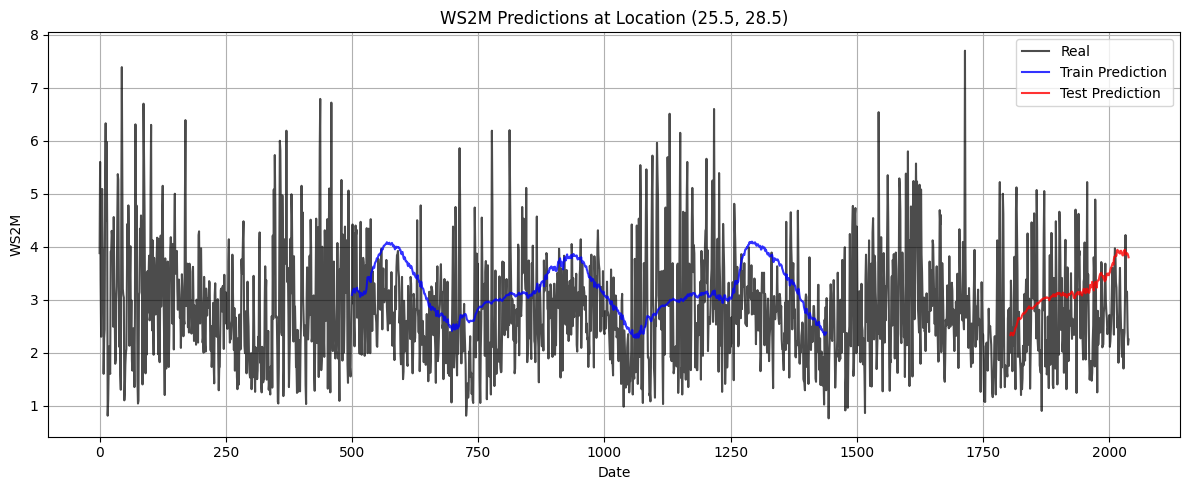

In [11]:
loc_idx = 0

# Get location coordinates
lon, lat = locations[loc_idx]

# Filter original dataframe for this location

real_values = datadict[feature_name][loc_idx].to_numpy()

# Get prediction arrays
y_train_pred = train_predictions[feature_name][loc_idx][:, -1]
y_test_pred = test_predictions[feature_name][loc_idx][:, -1]

# Get lengths
train_len = len(y_train_pred)
test_len = len(y_test_pred)
total_len = len(real_values)

# Create aligned arrays with NaNs
train_plot = np.full(total_len, np.nan)
test_plot = np.full(total_len, np.nan)

# Insert predictions in appropriate places
train_plot[look_back:look_back+train_len] = y_train_pred
test_plot[-test_len:] = y_test_pred

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(real_values, label="Real", color='black', alpha=0.7)
plt.plot(train_plot, label="Train Prediction", color='blue', alpha=0.8)
plt.plot(test_plot, label="Test Prediction", color='red', alpha=0.8)

plt.title(f"{feature_name} Predictions at Location ({lon}, {lat})")
plt.xlabel("Date")
plt.ylabel(feature_name)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [12]:
# Save directory
save_dir = "/kaggle/working/forecast_config"
os.makedirs(save_dir, exist_ok=True)

# Save feature names and settings
config = {
    'columns': columns,
    'locations': locations,
    'look_back': look_back,
    'look_forward': look_forward,
    'last_sequences': {
        feature: {
            i: feature_datasets[feature]['X_test'][i][-1]
            for i in range(len(locations))
        }
        for feature in columns
    },
    'last_date': str(df['Date'].max())  # Save as string for compatibility
}

# Save to disk
with open(os.path.join(save_dir, "forecast_config.pkl"), "wb") as f:
    pickle.dump(config, f)

print("Forecast configuration saved.")


Forecast configuration saved.


In [13]:
def load_models_and_forecast(config_path, models_path, forecast_days=100):
    import os
    import pickle
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    import datetime

    # Load config
    with open(config_path, "rb") as f:
        config = pickle.load(f)

    columns = config['columns']
    locations = config['locations']
    look_back = config['look_back']
    look_forward = config['look_forward']
    last_sequences = config['last_sequences']
    last_date = pd.to_datetime(config['last_date'])

    # Load models for each feature
    models = {}
    for feature_name in columns:
        model_path = os.path.join(models_path, f"model_{feature_name}.keras")
        models[feature_name] = tf.keras.models.load_model(model_path)
        print(f"Model loaded from {model_path}")

    forecast_results = {feature: [] for feature in columns}
    forecast_dates = [last_date + datetime.timedelta(days=j+1) for j in range(forecast_days)]

    print(f"\nStarting forecast generation for {len(columns)} features and {len(locations)} locations...")

    for feature_name in columns:
        model = models[feature_name]
        for loc_idx in range(len(locations)):
            print(f"Predicting {feature_name} at location {loc_idx+1}/{len(locations)}")

            # Get the last sequence for this feature and location
            input_sequence = np.array(last_sequences[feature_name][loc_idx]).reshape(1, look_back, 1)

            prediction = model.predict(input_sequence, verbose=0)[0]

            # Pad or truncate to match forecast_days
            if forecast_days <= look_forward:
                padded_prediction = prediction[:forecast_days]
            else:
                padded_prediction = np.concatenate([
                    prediction[:look_forward],
                    np.full(forecast_days - look_forward, prediction[-1])
                ])

            forecast_results[feature_name].append({
                'location': locations[loc_idx],
                'forecast': padded_prediction,
                'forecast_dates': forecast_dates
            })

    return forecast_results


In [14]:
config_path = "/kaggle/working/forecast_config/forecast_config.pkl"
models_path = "/kaggle/working"
results = load_models_and_forecast(config_path, models_path, forecast_days=365)


Model loaded from /kaggle/working/model_AIRMASS.keras
Model loaded from /kaggle/working/model_ALLSKY_SFC_SW_DWN.keras
Model loaded from /kaggle/working/model_CLOUD_AMT.keras
Model loaded from /kaggle/working/model_PSH.keras
Model loaded from /kaggle/working/model_PW.keras
Model loaded from /kaggle/working/model_GWETROOT.keras
Model loaded from /kaggle/working/model_GWETTOP.keras
Model loaded from /kaggle/working/model_PRECTOTCORR.keras
Model loaded from /kaggle/working/model_RH2M.keras
Model loaded from /kaggle/working/model_T2M.keras
Model loaded from /kaggle/working/model_TO3.keras
Model loaded from /kaggle/working/model_TS.keras
Model loaded from /kaggle/working/model_WS2M.keras

Starting forecast generation for 13 features and 90 locations...
Predicting AIRMASS at location 1/90
Predicting AIRMASS at location 2/90
Predicting AIRMASS at location 3/90
Predicting AIRMASS at location 4/90
Predicting AIRMASS at location 5/90
Predicting AIRMASS at location 6/90
Predicting AIRMASS at locat

Plotting forecasts for location (34.5, 24.5)


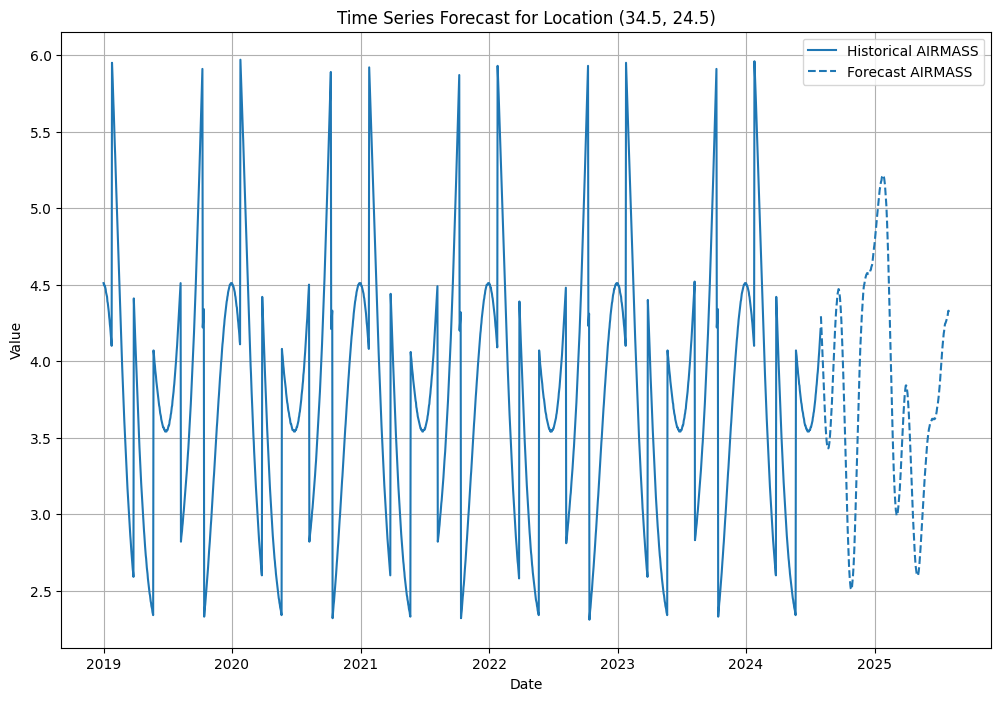

In [15]:
def visualize_forecasts(forecast_dict,
                        location_idx=0,  # Default to first location
                        location_key=None,
                        show_historical=True,
                        graph_cols=None,
                        data_file_path='/kaggle/input/applications/Applications.csv'):
    import matplotlib.pyplot as plt
    import pandas as pd

    # Load historical data
    df = pd.read_csv(data_file_path)
    df = df[~((df["DOY"] > 213) & (df["YEAR"] == 2024))]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(by=['Date'])

    # Get all feature names and infer number of locations
    all_columns = list(forecast_dict.keys())
    num_locations = len(next(iter(forecast_dict.values())))

    # Determine location from index or key
    if location_key is not None:
        # Initialize location_idx to None first
        location_idx = None
        # Reverse search to find location index
        for i in range(num_locations):
            if np.array_equal(forecast_dict[all_columns[0]][i]['location'], location_key):
                location_idx = i
                break
        if location_idx is None:
            print("Provided location_key not found. Using default location index 0.")
            location_idx = 0
    
    # Get the location coordinates
    lon, lat = forecast_dict[all_columns[0]][location_idx]['location']
    print(f"Plotting forecasts for location ({lon}, {lat})")

    # Use specified columns or all
    if graph_cols is None:
        graph_cols = all_columns

    # Get forecast dates (same for all features)
    forecast_dates = forecast_dict[graph_cols[0]][location_idx]['forecast_dates']

    # Plot setup
    plt.figure(figsize=(12, 8))
    colors = plt.cm.tab10.colors

    # Plot historical data
    if show_historical:
        data = df[(df['LON'] == lon) & (df['LAT'] == lat)]
        historical_dates = data['Date'].reset_index(drop=True)
        for i, col in enumerate(graph_cols):
            if col in data.columns:
                plt.plot(historical_dates, data[col].reset_index(drop=True),
                         color=colors[i % len(colors)], label=f"Historical {col}")

    # Plot forecasts
    for i, col in enumerate(graph_cols):
        if col in forecast_dict:
            forecast_values = forecast_dict[col][location_idx]['forecast']
            linestyle = '--' if show_historical else '-'
            plt.plot(forecast_dates, forecast_values,
                     color=colors[i % len(colors)], linestyle=linestyle,
                     label=f"Forecast {col}")

    plt.title(f"Time Series Forecast for Location ({lon}, {lat})")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

visualize_forecasts(
    forecast_dict=results,
    location_idx=1,
    show_historical=True,
    graph_cols=['AIRMASS']
)
